In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

In [6]:
df = pd.read_parquet("yellow_tripdata_2025-01.parquet")

In [7]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [8]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3475221,2,2025-01-31 23:01:48,2025-01-31 23:16:29,NaN,3.35,NaN,None,79,237,0,15.85,0.0,0.5,0.0,0.0,1.0,20.60,NaN,NaN,0.75
3475222,2,2025-01-31 23:50:29,2025-02-01 00:17:27,NaN,8.73,NaN,None,161,116,0,28.14,0.0,0.5,0.0,0.0,1.0,32.89,NaN,NaN,0.75
3475223,2,2025-01-31 23:26:59,2025-01-31 23:43:01,NaN,2.64,NaN,None,144,246,0,14.91,0.0,0.5,0.0,0.0,1.0,19.66,NaN,NaN,0.75
3475224,2,2025-01-31 23:14:34,2025-01-31 23:34:52,NaN,3.16,NaN,None,142,107,0,17.55,0.0,0.5,0.0,0.0,1.0,22.30,NaN,NaN,0.75
3475225,2,2025-01-31 23:56:42,2025-02-01 00:07:27,NaN,2.29,NaN,None,237,238,0,12.09,0.0,0.5,0.0,0.0,1.0,16.09,NaN,NaN,0.00


In [14]:
df.sample(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2835217,2,2025-01-31 01:24:42,2025-01-31 01:36:44,1.0,2.65,1.0,N,137,262,1,14.2,1.0,0.5,3.99,0.0,1.0,23.94,2.5,0.0,0.75
1402229,2,2025-01-16 12:26:09,2025-01-16 12:31:18,1.0,0.94,1.0,N,141,262,1,7.2,0.0,0.5,2.80,0.0,1.0,14.00,2.5,0.0,0.00
2351319,2,2025-01-25 23:54:51,2025-01-26 00:09:38,2.0,1.85,1.0,N,50,229,2,14.9,1.0,0.5,0.00,0.0,1.0,20.65,2.5,0.0,0.75
1339372,2,2025-01-15 18:02:40,2025-01-15 18:10:17,1.0,1.18,1.0,N,211,79,1,9.3,2.5,0.5,3.16,0.0,1.0,19.71,2.5,0.0,0.75
2882037,2,2025-01-31 15:50:35,2025-01-31 16:17:08,2.0,6.11,1.0,N,261,100,1,31.7,0.0,0.5,5.47,0.0,1.0,41.92,2.5,0.0,0.75


In [15]:
df.shape

(3475226, 20)

In [9]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')

In [17]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [19]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01
std,4.263282e-01,NaN,NaN,7.507503e-01,5.646016e+02,1.163277e+01,6.452948e+01,6.940169e+01,7.013334e-01,4.634729e+02,1.861509e+00,1.374623e-01,3.779681e+00,2.002582e+00,2.781938e-01,4.636585e+02,9.039932e-01,4.725090e-01,3.619307e-01


In [11]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [12]:
(df.isnull().mean()*100).sort_values(ascending=False)

Airport_fee              15.542845
passenger_count          15.542845
congestion_surcharge     15.542845
RatecodeID               15.542845
store_and_fwd_flag       15.542845
VendorID                  0.000000
mta_tax                   0.000000
total_amount              0.000000
improvement_surcharge     0.000000
tolls_amount              0.000000
tip_amount                0.000000
fare_amount               0.000000
extra                     0.000000
tpep_pickup_datetime      0.000000
payment_type              0.000000
DOLocationID              0.000000
PULocationID              0.000000
trip_distance             0.000000
tpep_dropoff_datetime     0.000000
cbd_congestion_fee        0.000000
dtype: float64

In [13]:
df.duplicated().sum()

0

In [8]:
df['passenger_count'] = (
    df['passenger_count']
    .fillna(df['passenger_count'].median())
)


In [11]:
df['RatecodeID'] = (
    df['RatecodeID']
    .fillna(df['RatecodeID'].mode()[0])
)

In [13]:
df['store_and_fwd_flag'] = (
    df['store_and_fwd_flag']
    .fillna('Unknown')
)

In [15]:
df['Airport_fee'] = (
    df['Airport_fee']
    .fillna(0)
)

In [17]:
df['congestion_surcharge'] = (
    df['congestion_surcharge']
    .fillna(0)
)

In [14]:
df.describe(include="all")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.475226e+06,3475226,3475226,2.935077e+06,3.475226e+06,2.935077e+06,2935077,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,3.475226e+06,2.935077e+06,2.935077e+06,3.475226e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,2927431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.785428e+00,2025-01-17 11:02:55.910964,2025-01-17 11:17:56.997901,1.297859e+00,5.855126e+00,2.482535e+00,NaN,1.651916e+02,1.641252e+02,1.036623e+00,1.708180e+01,1.317737e+00,4.780991e-01,2.959813e+00,4.493081e-01,9.547946e-01,2.561129e+01,2.225237e+00,1.239111e-01,4.834093e-01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-18 07:52:40,0.000000e+00,0.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00,-9.000000e+02,-7.500000e+00,-5.000000e-01,-8.600000e+01,-1.269400e+02,-1.000000e+00,-9.010000e+02,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2025-01-10 07:59:01,2025-01-10 08:15:29.500000,1.000000e+00,9.800000e-01,1.000000e+00,NaN,1.320000e+02,1.130000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.520000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2025-01-17 15:41:33,2025-01-17 15:59:34,1.000000e+00,1.670000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,1.211000e+01,0.000000e+00,5.000000e-01,2.450000e+00,0.000000e+00,1.000000e+00,1.995000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2025-01-24 19:34:06,2025-01-24 19:48:31,1.000000e+00,3.100000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,1.000000e+00,1.950000e+01,2.500000e+00,5.000000e-01,3.930000e+00,0.000000e+00,1.000000e+00,2.778000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2025-02-01 00:00:44,2025-02-01 23:44:11,9.000000e+00,2.764236e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,5.000000e+00,8.633721e+05,1.500000e+01,1.050000e+01,4.000000e+02,1.709400e+02,1.000000e+00,8.633804e+05,2.500000e+00,6.750000e+00,7.500000e-01


In [15]:
(df.isnull().mean()*100).sort_values(ascending=False)

Airport_fee              15.542845
passenger_count          15.542845
congestion_surcharge     15.542845
RatecodeID               15.542845
store_and_fwd_flag       15.542845
VendorID                  0.000000
mta_tax                   0.000000
total_amount              0.000000
improvement_surcharge     0.000000
tolls_amount              0.000000
tip_amount                0.000000
fare_amount               0.000000
extra                     0.000000
tpep_pickup_datetime      0.000000
payment_type              0.000000
DOLocationID              0.000000
PULocationID              0.000000
trip_distance             0.000000
tpep_dropoff_datetime     0.000000
cbd_congestion_fee        0.000000
dtype: float64

In [22]:
df[['passenger_count',
    'RatecodeID',
    'store_and_fwd_flag',
    'congestion_surcharge',
    'Airport_fee']].isna().sum()

passenger_count         0
RatecodeID              0
store_and_fwd_flag      0
congestion_surcharge    0
Airport_fee             0
dtype: int64

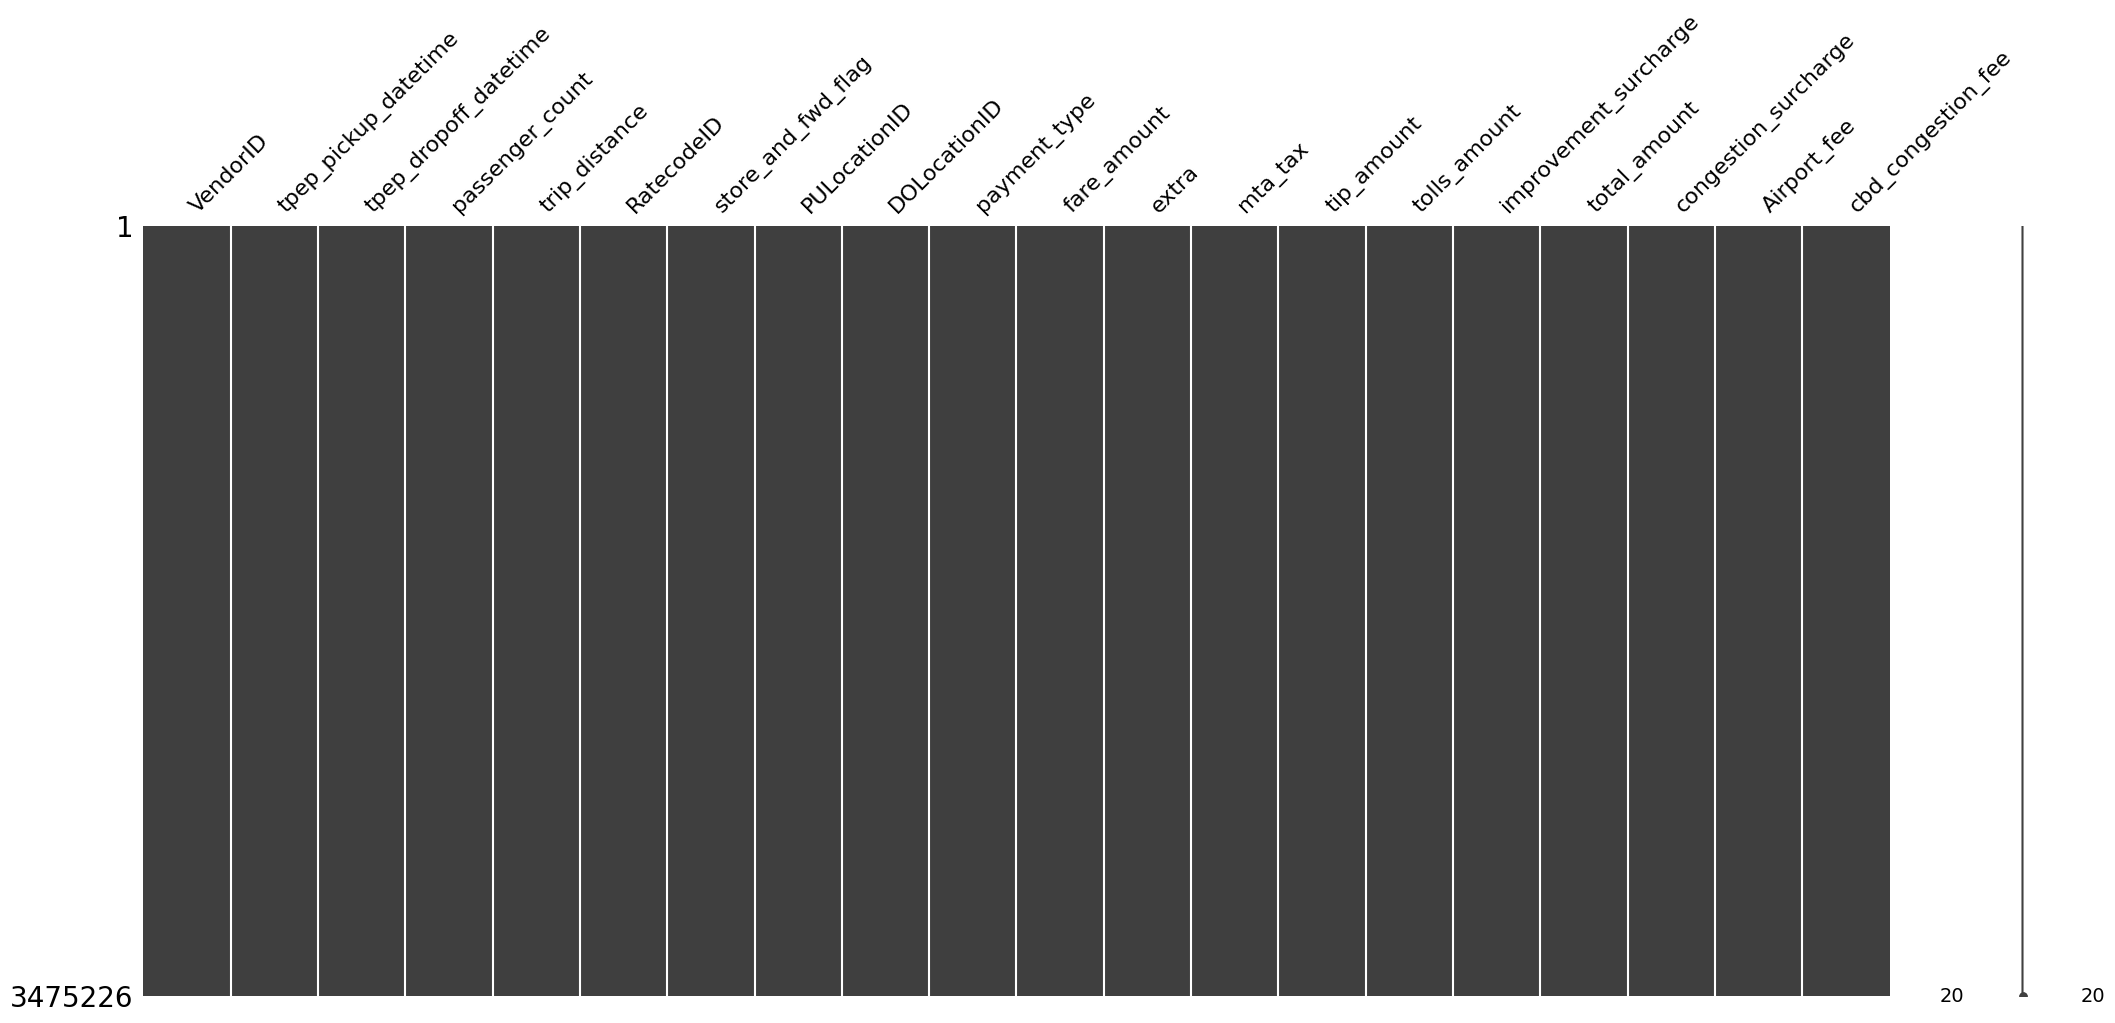

In [26]:
msno.matrix(df)
plt.show()

In [27]:
df.memory_usage(deep=True)

Index                          132
VendorID                  13900904
tpep_pickup_datetime      27801808
tpep_dropoff_datetime     27801808
passenger_count           27801808
trip_distance             27801808
RatecodeID                27801808
store_and_fwd_flag       204804002
PULocationID              13900904
DOLocationID              13900904
payment_type              27801808
fare_amount               27801808
extra                     27801808
mta_tax                   27801808
tip_amount                27801808
tolls_amount              27801808
improvement_surcharge     27801808
total_amount              27801808
congestion_surcharge      27801808
Airport_fee               27801808
cbd_congestion_fee        27801808
dtype: int64

In [28]:
df.memory_usage(deep=True).sum()/1024**2

659.3091716766357

In [29]:
df.nunique()

VendorID                       4
tpep_pickup_datetime     1672077
tpep_dropoff_datetime    1671993
passenger_count               10
trip_distance               4545
RatecodeID                     7
store_and_fwd_flag             3
PULocationID                 261
DOLocationID                 260
payment_type                   6
fare_amount                11538
extra                         77
mta_tax                        9
tip_amount                  4197
tolls_amount                1234
improvement_surcharge          4
total_amount               21995
congestion_surcharge           3
Airport_fee                    7
cbd_congestion_fee             3
dtype: int64

In [30]:
df["passenger_count"].value_counts()

passenger_count
1.0    2862583
2.0     407761
3.0      91409
4.0      59009
0.0      24656
5.0      17786
6.0      12004
8.0         11
7.0          4
9.0          3
Name: count, dtype: int64

In [4]:
df["payment_type"].value_counts()

payment_type
1    2444393
0     540149
2     390429
4      76481
3      23773
5          1
Name: count, dtype: int64

In [27]:
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

In [28]:
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

In [29]:
df["pickup_year"] = df["tpep_pickup_datetime"].dt.year

In [30]:
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month

In [31]:
df["weekday"] = df["tpep_pickup_datetime"].dt.day_name()

In [32]:
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

In [33]:
df["is_weekend"] = df["weekday"].isin(["Saturday","Sunday"])

Trip Duration

In [16]:
df["trip_duration"] = (
    df["tpep_dropoff_datetime"]-
    df["tpep_pickup_datetime"]
).dt.total_seconds()/60

In [15]:
df["trip_duration"].describe()

count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
max      5.626317e+03
Name: trip_duration, dtype: float64

Distance Analysis

In [16]:
df["trip_distance"].mean()

5.855126178844196

In [17]:
df["trip_distance"].median()

1.67

In [18]:
df["trip_distance"].max()

276423.57

In [19]:
df["trip_distance"].min()

0.0

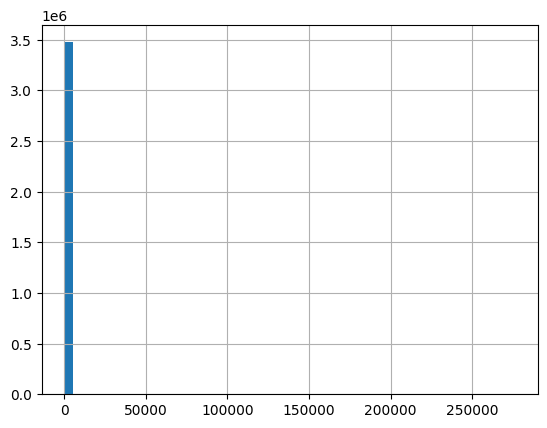

In [20]:
df["trip_distance"].hist(bins=50)
plt.show()

Fare Analysis

In [21]:
df["fare_amount"].mean()

17.081802760453577

In [22]:
df["fare_amount"].max()

863372.12

In [23]:
df["fare_amount"].min()

-900.0

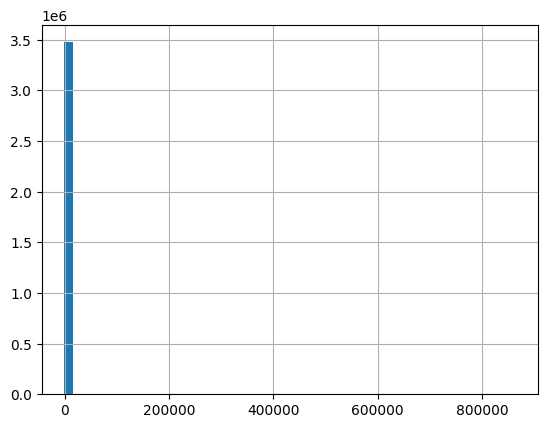

In [24]:
df["fare_amount"].hist(bins=50)
plt.show()

Total Amount Analysis

In [25]:
df["total_amount"].describe()

count    3.475226e+06
mean     2.561129e+01
std      4.636585e+02
min     -9.010000e+02
25%      1.520000e+01
50%      1.995000e+01
75%      2.778000e+01
max      8.633804e+05
Name: total_amount, dtype: float64

In [26]:
df.nlargest(10,"tip_amount")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
1583318,2,2025-01-17 23:31:29,2025-01-18 00:12:47,1.0,14.74,1.0,N,232,216,1,...,473.15,2.5,0.0,0.75,2025,1,Friday,23,False,41.300000
2329131,2,2025-01-25 19:11:06,2025-01-25 19:11:10,1.0,0.00,1.0,N,216,216,1,...,364.50,0.0,0.0,0.00,2025,1,Saturday,19,True,0.066667
2329130,2,2025-01-25 19:07:42,2025-01-25 19:08:50,1.0,0.00,1.0,N,216,216,1,...,338.53,0.0,0.0,0.00,2025,1,Saturday,19,True,1.133333
286175,2,2025-01-04 15:41:54,2025-01-04 15:52:27,2.0,1.73,1.0,N,161,237,1,...,349.40,2.5,0.0,0.00,2025,1,Saturday,15,True,10.550000
2315999,2,2025-01-25 18:24:51,2025-01-25 18:48:28,1.0,2.69,1.0,N,79,164,1,...,328.95,2.5,0.0,0.75,2025,1,Saturday,18,True,23.616667
1184297,2,2025-01-14 11:17:31,2025-01-14 11:51:28,1.0,17.29,1.0,N,231,138,1,...,360.14,0.0,0.0,0.00,2025,1,Tuesday,11,False,33.950000
250630,2,2025-01-04 03:31:55,2025-01-04 03:51:06,2.0,9.83,1.0,N,161,138,1,...,317.34,2.5,0.0,0.00,2025,1,Saturday,3,True,19.183333
413087,1,2025-01-06 00:16:24,2025-01-06 00:31:03,1.0,3.00,1.0,N,264,212,1,...,250.30,0.0,0.0,0.00,2025,1,Monday,0,False,14.650000
1527704,1,2025-01-17 14:36:05,2025-01-17 14:44:04,1.0,1.40,1.0,N,263,229,1,...,239.80,2.5,0.0,0.75,2025,1,Friday,14,False,7.983333
2666918,2,2025-01-29 15:17:36,2025-01-29 15:28:22,1.0,1.11,1.0,N,237,162,1,...,235.45,2.5,0.0,0.75,2025,1,Wednesday,15,False,10.766667


Outlier Detection

In [17]:
Q1=df["trip_distance"].quantile(.25)
Q3=df["trip_distance"].quantile(.75)

IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df["trip_distance"]<lower)|(df["trip_distance"]>upper)]

In [18]:
len(outliers)

422436

Correlation

In [19]:
corr=df.corr(numeric_only=True)

corr

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
VendorID,1.000000,0.109692,0.002373,-0.213959,-0.006897,-0.005810,-0.004040,-0.001574,-0.532195,-0.064030,0.012824,-0.001718,0.005708,-0.001300,0.010966,0.033776,0.024847,-0.009063
passenger_count,0.109692,1.000000,0.003609,-0.045093,-0.010883,-0.006710,0.028031,0.001374,-0.065410,-0.030052,0.020370,0.028888,0.002661,0.001637,-0.001903,0.019702,-0.023705,0.016918
trip_distance,0.002373,0.003609,1.000000,0.022977,-0.001946,-0.002209,-0.006932,0.000182,-0.002486,0.000327,0.000334,0.003809,0.000018,0.000201,-0.026774,0.060379,-0.000847,0.002113
RatecodeID,-0.213959,-0.045093,0.022977,1.000000,-0.085538,-0.072965,-0.043661,0.004420,-0.098577,0.006502,-0.094625,0.073838,-0.327924,0.002906,-0.303157,-0.022954,-0.157824,0.089634
PULocationID,-0.006897,-0.010883,-0.001946,-0.085538,1.000000,0.086798,0.017246,-0.004137,-0.011122,0.017012,-0.039499,-0.069267,0.036775,-0.004792,0.118946,-0.143462,-0.076320,-0.034857
DOLocationID,-0.005810,-0.006710,-0.002209,-0.072965,0.086798,1.000000,0.015104,-0.004088,0.019548,0.023762,-0.017333,-0.049152,0.032639,-0.004276,0.111679,-0.044834,-0.055314,-0.029903
payment_type,-0.004040,0.028031,-0.006932,-0.043661,0.017246,0.015104,1.000000,-0.000650,0.097595,-0.424528,-0.066118,0.002248,-0.412525,-0.002365,-0.418928,-0.026932,-0.159221,-0.006559
fare_amount,-0.001574,0.001374,0.000182,0.004420,-0.004137,-0.004088,-0.000650,1.000000,0.007880,0.005531,0.021010,0.022383,0.008962,0.999913,-0.003113,0.023500,-0.000686,0.007804
extra,-0.532195,-0.065410,-0.002486,-0.098577,-0.011122,0.019548,0.097595,0.007880,1.000000,0.160220,0.271233,0.219483,0.181917,0.013966,0.139416,0.311773,0.069912,0.021942
mta_tax,-0.064030,-0.030052,0.000327,0.006502,0.017012,0.023762,-0.424528,0.005531,0.160220,1.000000,0.028990,-0.037894,0.856520,0.008489,0.697831,0.097272,0.203666,-0.001057


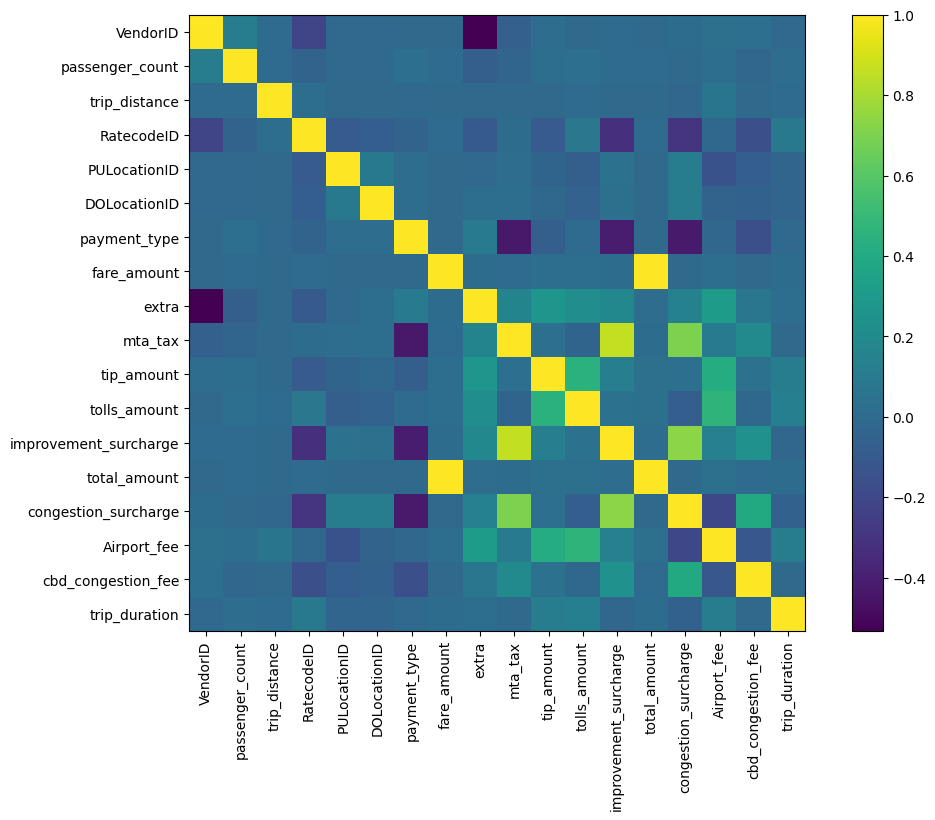

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.show()

GroupBy Questions

In [32]:
df.groupby("payment_type")["fare_amount"].mean()

payment_type
0    14.587529
1    18.008540
2    16.603058
3     4.498180
4    11.434029
5     0.000000
Name: fare_amount, dtype: float64

In [33]:
df.groupby("passenger_count")["trip_distance"].mean()

passenger_count
0.0     2.434000
1.0     3.094355
2.0     3.681512
3.0     3.483201
4.0     3.723703
5.0     2.938389
6.0     3.070723
7.0     0.005000
8.0     6.340000
9.0    14.863333
Name: trip_distance, dtype: float64

In [34]:
df.groupby("VendorID")["total_amount"].sum()

VendorID
1    20183067.41
2    68780553.52
6       14985.67
7       26420.20
Name: total_amount, dtype: float64

Sorting

In [35]:
df.nlargest(20,"total_amount")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
1780915,1,2025-01-20 12:07:18,2025-01-20 12:12:42,1.0,1.60,1.0,N,138,8,4,...,863380.37,0.0,1.75,0.00,2025,1,Monday,12,False,5.400000
1404958,2,2025-01-16 12:23:14,2025-01-17 14:41:56,1.0,255.33,4.0,N,161,265,2,...,2506.71,0.0,0.00,0.75,2025,1,Thursday,12,False,1578.700000
1832645,2,2025-01-21 05:17:57,2025-01-21 08:19:45,1.0,188.88,4.0,N,247,265,2,...,1311.70,0.0,0.00,0.00,2025,1,Tuesday,5,False,181.800000
1346041,2,2025-01-15 19:14:42,2025-01-15 21:46:13,1.0,143.54,4.0,N,132,265,1,...,969.05,0.0,1.75,0.00,2025,1,Wednesday,19,False,151.516667
2358832,2,2025-01-26 00:04:04,2025-01-26 00:04:42,4.0,0.00,5.0,N,142,142,2,...,953.50,2.5,0.00,0.00,2025,1,Sunday,0,True,0.633333
2358836,2,2025-01-26 00:22:47,2025-01-26 00:22:55,4.0,0.00,5.0,N,226,226,2,...,951.00,0.0,0.00,0.00,2025,1,Sunday,0,True,0.133333
2358837,2,2025-01-26 00:24:25,2025-01-26 00:24:35,4.0,0.00,5.0,N,226,226,2,...,951.00,0.0,0.00,0.00,2025,1,Sunday,0,True,0.166667
2358828,2,2025-01-26 00:00:56,2025-01-26 00:01:06,4.0,0.00,5.0,N,142,142,2,...,903.50,2.5,0.00,0.00,2025,1,Sunday,0,True,0.166667
2353880,2,2025-01-25 23:56:58,2025-01-25 23:57:06,4.0,0.00,5.0,N,142,142,2,...,903.49,2.5,0.00,0.00,2025,1,Saturday,23,True,0.133333
2353881,2,2025-01-25 23:58:50,2025-01-25 23:59:00,4.0,0.00,5.0,N,142,142,2,...,903.49,2.5,0.00,0.00,2025,1,Saturday,23,True,0.166667


In [21]:
df.nsmallest(20,"trip_distance")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration
92,1,2025-01-01 00:49:48,2025-01-01 00:49:48,1.0,0.0,1.0,Y,87,264,2,...,0.0,0.0,0.00,0.00,0.0,20.06,0.0,0.0,0.0,0.000000
204,2,2025-01-01 00:37:43,2025-01-01 00:37:53,1.0,0.0,5.0,N,148,148,1,...,0.0,0.0,2.00,0.00,1.0,17.50,2.5,0.0,0.0,0.166667
358,2,2025-01-01 00:57:08,2025-01-01 00:57:16,3.0,0.0,5.0,N,141,141,1,...,0.0,0.0,0.00,0.00,1.0,33.50,2.5,0.0,0.0,0.133333
505,1,2025-01-01 00:27:40,2025-01-01 00:59:30,1.0,0.0,1.0,N,168,76,1,...,0.0,0.5,0.00,6.94,1.0,58.94,0.0,0.0,0.0,31.833333
619,2,2025-01-01 00:56:49,2025-01-01 00:56:54,4.0,0.0,5.0,N,164,164,1,...,0.0,0.0,7.05,0.00,1.0,30.55,2.5,0.0,0.0,0.083333
706,1,2025-01-01 00:42:42,2025-01-01 00:42:44,0.0,0.0,1.0,N,261,261,1,...,3.5,0.5,2.35,0.00,1.0,10.35,2.5,0.0,0.0,0.033333
1073,1,2025-01-01 00:43:22,2025-01-01 00:46:18,1.0,0.0,5.0,N,48,48,1,...,0.0,0.0,3.00,0.00,1.0,9.00,0.0,0.0,0.0,2.933333
1345,2,2025-01-01 00:24:26,2025-01-01 00:24:34,4.0,0.0,5.0,N,60,60,1,...,0.0,0.0,4.20,0.00,1.0,25.20,0.0,0.0,0.0,0.133333
1354,1,2025-01-01 00:14:57,2025-01-01 00:17:44,1.0,0.0,1.0,N,79,79,3,...,3.5,0.5,0.00,0.00,1.0,8.00,2.5,0.0,0.0,2.783333
1496,2,2025-01-01 00:49:10,2025-01-01 00:49:14,4.0,0.0,5.0,N,143,143,1,...,0.0,0.0,26.55,0.00,1.0,115.05,2.5,0.0,0.0,0.066667


Filtering Questions

In [37]:
df[df["trip_distance"]>50]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
9215,1,2025-01-01 01:04:01,2025-01-01 03:33:22,2.0,133.30,5.0,N,68,265,1,...,380.88,0.0,0.00,0.00,2025,1,Wednesday,1,False,149.350000
10040,2,2025-01-01 01:05:24,2025-01-01 02:35:52,4.0,97.42,5.0,N,48,265,1,...,311.00,0.0,0.00,0.00,2025,1,Wednesday,1,False,90.466667
21389,2,2025-01-01 04:51:56,2025-01-01 07:03:12,1.0,97.58,5.0,N,246,265,2,...,386.38,0.0,0.00,0.00,2025,1,Wednesday,4,False,131.266667
23677,2,2025-01-01 06:02:52,2025-01-01 06:29:25,3.0,94.88,2.0,N,265,75,1,...,94.13,0.0,0.00,0.00,2025,1,Wednesday,6,False,26.550000
23791,2,2025-01-01 06:46:17,2025-01-01 07:53:15,1.0,61.06,4.0,N,132,265,1,...,357.43,0.0,1.75,0.00,2025,1,Wednesday,6,False,66.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3451364,1,2025-01-31 12:52:40,2025-01-31 13:02:57,NaN,56.30,NaN,None,140,237,0,...,14.24,NaN,NaN,0.75,2025,1,Friday,12,False,10.283333
3461154,2,2025-01-31 18:33:00,2025-01-31 18:53:00,NaN,71976.78,NaN,None,41,243,0,...,29.58,NaN,NaN,0.00,2025,1,Friday,18,False,20.000000
3461434,2,2025-01-31 18:13:00,2025-01-31 18:21:00,NaN,88102.25,NaN,None,48,161,0,...,5.08,NaN,NaN,0.75,2025,1,Friday,18,False,8.000000
3464668,2,2025-01-31 19:24:00,2025-01-31 19:35:00,NaN,60677.15,NaN,None,170,113,0,...,14.91,NaN,NaN,0.75,2025,1,Friday,19,False,11.000000


In [38]:
df[df["fare_amount"]>100]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
823,2,2025-01-01 00:49:36,2025-01-01 02:11:46,4.0,24.70,1.0,N,68,82,3,...,123.44,2.5,0.00,0.00,2025,1,Wednesday,0,False,82.166667
902,2,2025-01-01 00:05:17,2025-01-01 00:54:59,2.0,29.61,3.0,N,138,265,1,...,190.23,0.0,1.75,0.00,2025,1,Wednesday,0,False,49.700000
918,1,2025-01-01 00:35:40,2025-01-01 01:11:54,3.0,29.40,4.0,N,132,265,2,...,192.40,0.0,0.00,0.00,2025,1,Wednesday,0,False,36.233333
1064,2,2025-01-01 00:08:31,2025-01-01 00:46:27,3.0,27.11,4.0,N,132,265,1,...,151.35,0.0,1.75,0.00,2025,1,Wednesday,0,False,37.933333
2221,2,2025-01-01 00:11:07,2025-01-01 00:53:06,1.0,31.71,4.0,N,132,265,1,...,183.35,0.0,1.75,0.00,2025,1,Wednesday,0,False,41.983333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3427645,2,2025-01-30 09:48:53,2025-01-30 10:45:54,NaN,31.65,NaN,None,238,132,0,...,128.43,NaN,NaN,0.00,2025,1,Thursday,9,False,57.016667
3431497,2,2025-01-30 16:58:28,2025-01-30 17:57:48,NaN,25.56,NaN,None,117,168,0,...,112.79,NaN,NaN,0.00,2025,1,Thursday,16,False,59.333333
3434759,2,2025-01-30 18:34:53,2025-01-30 19:35:55,NaN,21.48,NaN,None,48,265,0,...,118.57,NaN,NaN,0.75,2025,1,Thursday,18,False,61.033333
3445082,2,2025-01-31 00:48:25,2025-01-31 02:52:26,NaN,100.69,NaN,None,161,265,0,...,305.38,NaN,NaN,0.75,2025,1,Friday,0,False,124.016667


In [39]:
df[df["tip_amount"]>50]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pickup_year,pickup_month,weekday,pickup_hour,is_weekend,trip_duration
8251,2,2025-01-01 01:25:26,2025-01-01 03:06:46,2.0,49.98,4.0,N,186,265,1,...,406.90,0.0,0.00,0.00,2025,1,Wednesday,1,False,101.333333
8627,2,2025-01-01 01:15:38,2025-01-01 02:20:10,4.0,36.92,5.0,N,161,265,1,...,301.20,0.0,0.00,0.00,2025,1,Wednesday,1,False,64.533333
10601,2,2025-01-01 01:09:12,2025-01-01 01:20:32,2.0,0.48,1.0,N,234,234,1,...,115.69,2.5,0.00,0.00,2025,1,Wednesday,1,False,11.333333
11672,2,2025-01-01 01:02:49,2025-01-01 01:08:46,1.0,3.80,1.0,N,132,157,1,...,78.55,0.0,1.75,0.00,2025,1,Wednesday,1,False,5.950000
12161,2,2025-01-01 02:01:05,2025-01-01 02:01:13,3.0,0.00,1.0,N,41,41,1,...,87.50,0.0,0.00,0.00,2025,1,Wednesday,2,False,0.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914094,2,2025-01-31 20:54:40,2025-01-31 21:35:08,1.0,18.74,2.0,N,132,249,1,...,183.43,2.5,1.75,0.75,2025,1,Friday,20,False,40.466667
2923834,2,2025-01-31 21:18:07,2025-01-31 22:38:01,1.0,65.65,4.0,N,132,265,1,...,480.53,0.0,1.75,0.00,2025,1,Friday,21,False,79.900000
2927427,2,2025-01-31 22:16:29,2025-01-31 22:16:41,1.0,0.00,1.0,N,90,90,1,...,68.75,2.5,0.00,0.75,2025,1,Friday,22,False,0.200000
2931178,2,2025-01-31 23:25:51,2025-01-31 23:44:24,3.0,6.93,1.0,N,138,168,1,...,96.54,0.0,1.75,0.00,2025,1,Friday,23,False,18.550000


Peak Hours

In [40]:
df.groupby("pickup_hour").size()

pickup_hour
0      93417
1      64484
2      43929
3      28492
4      20033
5      22551
6      50026
7     102581
8     141305
9     142877
10    148316
11    160076
12    175432
13    186144
14    202289
15    213694
16    217051
17    253518
18    267951
19    221055
20    195001
21    205978
22    182214
23    136812
dtype: int64

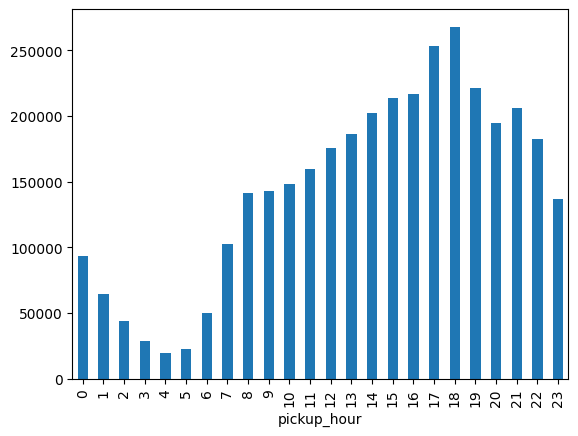

In [41]:
df.groupby("pickup_hour").size().plot(kind="bar")
plt.show()

Busiest Days

In [34]:
df.groupby("weekday").size()

weekday
Friday       586863
Monday       363772
Saturday     476399
Sunday       402594
Thursday     614230
Tuesday      453993
Wednesday    577375
dtype: int64

In [35]:
df["speed"]=(df["trip_distance"]/(df["trip_duration"]/60))

In [36]:
df["speed"].describe()

C:\Users\Projit\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    3.474534e+06
mean              inf
std               NaN
min     -6.436800e+04
25%      7.209809e+00
50%      9.519231e+00
75%      1.293839e+01
max               inf
Name: speed, dtype: float64

In [39]:
df["tip_percent"]=(
    df["tip_amount"]/df["fare_amount"]
)*100

In [43]:
df["tip_percent"].mean()

inf

In [44]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee', 'trip_duration', 'speed', 'weekday',
       'pickup_year', 'pickup_month', 'pickup_hour', 'is_weekend',
       'tip_percent'],
      dtype='object')

Revenue Analysis

In [46]:
df.groupby("weekday")["total_amount"].sum()

weekday
Friday       14997333.87
Monday       10584363.37
Saturday     11363736.75
Sunday       10190237.65
Thursday     15863551.34
Tuesday      11509452.78
Wednesday    14496351.04
Name: total_amount, dtype: float64

In [47]:
df.groupby("pickup_hour")["total_amount"].sum()

pickup_hour
0     2371982.77
1     1504284.38
2      973494.86
3      644218.37
4      560345.33
5      714342.51
6     1356957.11
7     2599478.08
8     3410758.24
9     3496775.88
10    3672648.45
11    3927036.05
12    5206860.59
13    4715047.41
14    5268653.56
15    5573589.56
16    6029906.12
17    6565618.13
18    6566541.38
19    5575551.51
20    4921270.10
21    5193015.73
22    4622288.63
23    3534362.05
Name: total_amount, dtype: float64

Payment Type Distribution

In [48]:
df["payment_type"].value_counts(normalize=True)*100

payment_type
1    70.337670
0    15.542845
2    11.234636
4     2.200749
3     0.684071
5     0.000029
Name: proportion, dtype: float64

Vendor Comparison

In [49]:
df["VendorID"].value_counts()

VendorID
2    2719860
1     753671
7       1206
6        489
Name: count, dtype: int64

In [50]:
df.groupby("VendorID")["total_amount"].sum()

VendorID
1    20183067.41
2    68780553.52
6       14985.67
7       26420.20
Name: total_amount, dtype: float64

In [51]:
df.groupby("VendorID")["fare_amount"].mean()

VendorID
1    18.447616
2    16.707627
6     2.968200
7    13.128607
Name: fare_amount, dtype: float64

Location Analysis

In [52]:
df["PULocationID"].value_counts().head(20)

PULocationID
161    169977
237    163703
236    155647
132    146137
230    125829
186    119131
162    117930
142    110585
239     96614
163     95906
234     95896
170     95636
68      91241
138     89658
48      84137
141     81661
79      81576
249     77355
164     76066
140     75093
Name: count, dtype: int64

In [53]:
df["DOLocationID"].value_counts().head(20)

DOLocationID
236    161376
237    149970
161    131258
230    108177
170    100060
142     98982
239     97559
162     93798
141     92675
68      89232
234     84669
163     84631
48      82722
238     78467
186     76338
79      76009
140     74165
263     73889
164     72594
229     71480
Name: count, dtype: int64

Categorical Analysis

In [54]:
categorical=df.select_dtypes(include="object")

categorical.columns

Index(['store_and_fwd_flag', 'weekday'], dtype='object')

In [55]:
numeric=df.select_dtypes(include=np.number)

numeric.columns

Index(['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee', 'trip_duration', 'speed', 'pickup_year',
       'pickup_month', 'pickup_hour', 'tip_percent'],
      dtype='object')

Boxplots

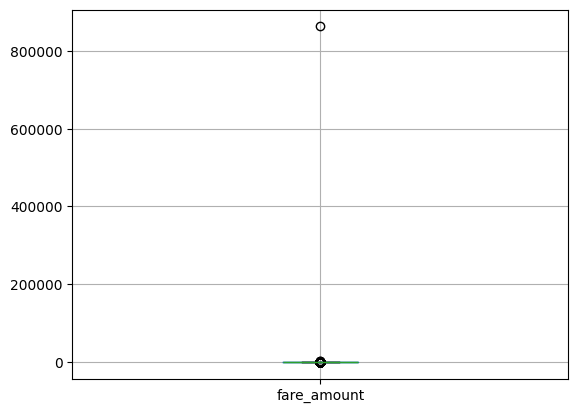

In [58]:
df.boxplot(column="fare_amount")
plt.show()

In [59]:
df["fare_amount"].quantile([0.25,0.5,0.75,0.90,0.95,0.99])

0.25     8.60
0.50    12.11
0.75    19.50
0.90    34.98
0.95    52.00
0.99    72.30
Name: fare_amount, dtype: float64